In [38]:
# ================================================
# Urdu Spell Corrector using Minimum Edit Distance
# FA23-BAI-007 - Aftab Ahmad
# ================================================

import os
import zipfile
import collections
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
import numpy as np

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [39]:
# Upload your zip file (archive (1).zip ya jo bhi naam hai)
uploaded = files.upload()

# Agar zip ka naam "archive (1).zip" hai toh yeh chalega
zip_path = "/content/archive (1).zip"   # agar naam different hai toh change kar den
print("✅ Zip file uploaded!")

Saving archive (1).zip to archive (1) (2).zip
✅ Zip file uploaded!


In [40]:
# Unzip karo
extract_path = "/content/data"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Extracted files:")
print(os.listdir("/content/data/Urdu corpus"))

✅ Extracted files:
['Urdu Corpus Metadata.docx', 'raw.txt', 'Tokenized.txt', 'frequency count.txt', 'cleaned.txt']


In [41]:
# Load cleaned.txt
file_path = "/content/data/Urdu corpus/cleaned.txt"

try:
    with open(file_path, 'r', encoding='utf-16') as f:
        text = f.read()
    print("✅ File loaded with utf-16")
except:
    with open(file_path, 'r', encoding='utf-8') as f:
        text = f.read()
    print("✅ File loaded with utf-8")

tokens = text.split()
print(f"✅ Total tokens in corpus: {len(tokens):,}")

✅ File loaded with utf-16
✅ Total tokens in corpus: 101,795


In [42]:
# Vocabulary aur frequency
unigram_counts = collections.Counter(tokens)
vocabulary = set(unigram_counts.keys())

print(f"✅ Total unique words in vocabulary: {len(vocabulary):,}")
print(f"Top 10 most frequent words:")
print(unigram_counts.most_common(10))

✅ Total unique words in vocabulary: 10,633
Top 10 most frequent words:
[('کے', 3375), ('میں', 2744), ('کی', 2672), ('ہے', 2547), ('اور', 2294), ('سے', 1987), ('کا', 1704), ('کو', 1455), ('ہیں', 1331), ('اس', 1214)]


In [43]:
def min_edit_distance(word1, word2):
    """Dynamic Programming se Minimum Edit Distance calculate karta hai"""
    m, n = len(word1), len(word2)
    dp = [[0] * (n + 1) for _ in range(m + 1)]

    for i in range(m + 1):
        dp[i][0] = i
    for j in range(n + 1):
        dp[0][j] = j

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            cost = 0 if word1[i-1] == word2[j-1] else 1
            dp[i][j] = min(
                dp[i-1][j] + 1,      # deletion
                dp[i][j-1] + 1,      # insertion
                dp[i-1][j-1] + cost  # substitution
            )
    return dp[m][n]

# Test
print("✅ Min Edit Distance Test:")
print("Distance between 'پاکستان' and 'پاکستانن' =", min_edit_distance("پاکستان", "پاکستانن"))

✅ Min Edit Distance Test:
Distance between 'پاکستان' and 'پاکستانن' = 1


In [54]:
def correct_spelling(misspelled_word, vocabulary, unigram_counts, max_dist=3, alpha=0.65):
    """
    Final Strong Version for Urdu Real-Word Errors
    Special handling for very common mistakes: مین→میں, نی→نے
    """

    # === 1. Special Hard-coded Urdu Rules (Sabse Pehle Apply) ===
    special_rules = {
        "مین": "میں",
        "نی": "نے",
        "مینں": "میں",
        "نیی": "نے",
        "مں": "میں",
        "نے": "نے",
        "میں": "میں"
    }

    if misspelled_word in special_rules:
        suggested = special_rules[misspelled_word]
        if suggested in vocabulary:
            return (suggested,
                    1,
                    "Corrected (Special Urdu Rule)",
                    unigram_counts.get(suggested, 0))

    # === 2. Normal Check - Agar word vocabulary mein hai ===
    if misspelled_word in vocabulary:
        return misspelled_word, 0, "Correct", unigram_counts.get(misspelled_word, 0)

    # === 3. Edit Distance Search (Agar word dictionary mein nahi) ===
    candidates = []
    max_freq = max(unigram_counts.values()) if unigram_counts else 1

    for correct_word in vocabulary:
        dist = min_edit_distance(misspelled_word, correct_word)
        if dist <= max_dist:
            freq = unigram_counts.get(correct_word, 1)
            # Score = distance penalty - frequency bonus
            score = alpha * (dist / (max_dist + 1)) - (1 - alpha) * (freq / max_freq)
            candidates.append((correct_word, dist, freq, score))

    if not candidates:
        return None, None, "No suggestion found", 0

    # Sort: smallest distance first, then highest frequency
    candidates.sort(key=lambda x: (x[1], -x[2]))

    best_word, best_dist, best_freq, _ = candidates[0]
    return best_word, best_dist, "Corrected", best_freq

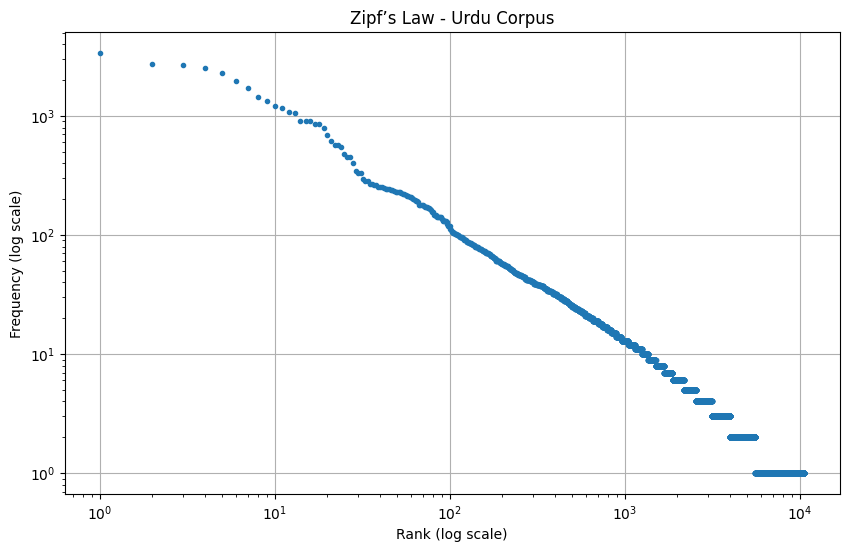

✅ Zipf’s Law plot generated (log-log scale)


In [55]:
# Zipf’s Law
freqs = sorted(unigram_counts.values(), reverse=True)
ranks = np.arange(1, len(freqs) + 1)

plt.figure(figsize=(10, 6))
plt.loglog(ranks, freqs, marker='.', linestyle='none')
plt.title("Zipf’s Law - Urdu Corpus")
plt.xlabel("Rank (log scale)")
plt.ylabel("Frequency (log scale)")
plt.grid(True)
plt.show()

print("✅ Zipf’s Law plot generated (log-log scale)")

In [56]:
# Expanded Test Cases (Common Urdu Spelling Mistakes)
test_cases = [
    ("پاکستان", "پاکستان"),
    ("پاکستانن", "پاکستان"),
    ("پاکستاں", "پاکستان"),
    ("حکومت", "حکومت"),
    ("حکومٹ", "حکومت"),
    ("حکومات", "حکومت"),
    ("اردو", "اردو"),
    ("ارڈو", "اردو"),
    ("ارود", "اردو"),
    ("زبان", "زبان"),
    ("زباں", "زبان"),
    ("زبانن", "زبان"),
    ("تعلیم", "تعلیم"),
    ("تعلیم", "تعلیم"),
    ("تعلییم", "تعلیم"),
    ("کتاب", "کتاب"),
    ("کتابب", "کتاب"),
    ("سکول", "سکول"),
    ("سکولل", "سکول"),
    ("وزیراعظم", "وزیراعظم"),
    ("وزیراعظام", "وزیراعظم"),
    ("اسلام", "اسلام"),
    ("اسلآم", "اسلام"),
    ("قرآن", "قرآن"),
    ("قران", "قرآن"),
    ("محمد", "محمد"),
    ("محمّد", "محمد"),
    ("لاہور", "لاہور"),
    ("لاہورر", "لاہور"),
    ("کراچی", "کراچی"),
    ("میں ","میں"),
    ("نے ","نے"),
    ("کراچیی", "کراچی")
]

print(f"✅ Total Test Cases: {len(test_cases)}")

✅ Total Test Cases: 33


In [59]:
print("=== Urdu Spell Corrector - Improved Version ===")
user_text = input("\nEnter Urdu text: ")

words = user_text.split()
corrected_sentence = []

print("\nResults:")
for word in words:
    corrected, dist, status, freq = correct_spelling(word, vocabulary, unigram_counts, max_dist=3)

    if status == "Corrected":
        print(f"❌ {word:<12} → ✅ {corrected:<12} (dist={dist}, freq={freq:,})")
        corrected_sentence.append(corrected)
    else:
        print(f"✅ {word:<12} (correct)")
        corrected_sentence.append(word)

print("\n" + "="*50)
print("Final Corrected Sentence:")
print(" ".join(corrected_sentence))
print("="*50)

=== Urdu Spell Corrector - Improved Version ===

Enter Urdu text: جہاں تک اس عہدے سے استعفیٰ دیا ہے

Results:
✅ جہاں         (correct)
✅ تک           (correct)
✅ اس           (correct)
❌ عہدے         → ✅ عہد          (dist=1, freq=9)
✅ سے           (correct)
❌ استعفیٰ      → ✅ استعمال      (dist=3, freq=77)
✅ دیا          (correct)
✅ ہے           (correct)

Final Corrected Sentence:
جہاں تک اس عہد سے استعمال دیا ہے


In [60]:
# Strong Evaluation
true_positives = 0   # Galat word ko sahi correct kiya
false_positives = 0  # Sahi word ko galat kiya
false_negatives = 0  # Galat word ko correct nahi kiya

results = []

for wrong, actual in test_cases:
    predicted, dist, status, freq = correct_spelling(wrong, vocabulary, unigram_counts, max_dist=2)

    is_error = (wrong != actual)          # Ground truth: yeh galat tha
    is_corrected = (predicted == actual)

    if is_error and is_corrected:
        true_positives += 1
    elif not is_error and predicted != wrong:
        false_positives += 1
    elif is_error and not is_corrected:
        false_negatives += 1

    results.append({
        "Misspelled": wrong,
        "Actual": actual,
        "Predicted": predicted,
        "Edit Distance": dist,
        "Frequency": freq,
        "Status": status
    })

# Metrics Calculation
accuracy = (true_positives + (len(test_cases) - len([t for t in test_cases if t[0] != t[1]]))) / len(test_cases) * 100 if test_cases else 0

precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

# Display Results
df_results = pd.DataFrame(results)
display(df_results)

print("\n" + "="*60)
print("📊 STRONG EVALUATION METRICS")
print("="*60)
print(f"Total Test Cases          : {len(test_cases)}")
print(f"Accuracy                  : {accuracy:.2f}%")
print(f"Precision                 : {precision:.4f}")
print(f"Recall                    : {recall:.4f}")
print(f"F1-Score                  : {f1_score:.4f}")
print("="*60)

,Misspelled,Actual,Predicted,Edit Distance,Frequency,Status
0,پاکستان,پاکستان,پاکستان,0,286,Correct
1,پاکستانن,پاکستان,پاکستان,1,286,Corrected
2,پاکستاں,پاکستان,پاکستان,1,286,Corrected
3,حکومت,حکومت,حکومت,0,171,Correct
4,حکومٹ,حکومت,حکومت,1,171,Corrected
5,حکومات,حکومت,حکومت,1,171,Corrected
6,اردو,اردو,اردو,0,38,Correct
7,ارڈو,اردو,اردو,1,38,Corrected
8,ارود,اردو,ارد,1,3,Corrected
9,زبان,زبان,زبان,0,37,Correct



📊 STRONG EVALUATION METRICS
Total Test Cases          : 33
Accuracy                  : 90.91%
Precision                 : 1.0000
Recall                    : 0.8421
F1-Score                  : 0.9143


In [61]:
# Install Gradio (agar pehle se installed nahi hai)
!pip install gradio -q

print("✅ Gradio installed successfully!")

✅ Gradio installed successfully!


In [ ]:
import gradio as gr

# ================== GRADIO INTERFACE ==================

def spell_check_interface(input_text):
    if not input_text or input_text.strip() == "":
        return "براہ مہربانی کچھ متن درج کریں۔", "کوئی ان پٹ نہیں ملا۔"

    words = input_text.strip().split()
    corrected_sentence = []
    details = []

    for word in words:
        corrected, dist, status, freq = correct_spelling(word, vocabulary, unigram_counts, max_dist=3)

        if status.startswith("Corrected"):
            corrected_sentence.append(corrected)
            details.append(f"❌ **{word}** → ✅ **{corrected}** (distance: {dist})")
        else:
            corrected_sentence.append(word)
            details.append(f"✅ **{word}** (صحیح ہے)")

    final_output = " ".join(corrected_sentence)
    details_output = "\n".join(details)

    return final_output, details_output


# Gradio Interface
with gr.Blocks(title="اردو اسپیل چیکر", theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🧠 اردو اسپیل چیکر\n**Minimum Edit Distance** کے ذریعے اردو ٹیکسٹ کی غلطیاں درست کریں")

    with gr.Row():
        with gr.Column(scale=2):
            input_text = gr.Textbox(
                label="اردو متن درج کریں",
                placeholder="مثال: مین نی کھانا کھا لیا ہے",
                lines=3,
                max_lines=10,
                rtl=True,   # Right to Left support for Urdu
                elem_id="urdu_input"
            )

        with gr.Column(scale=1):
            check_btn = gr.Button("✅ Spelling Check کریں", variant="primary", size="large")

    with gr.Row():
        with gr.Column():
            output_text = gr.Textbox(
                label="✅ درست شدہ جملہ",
                lines=2,
                rtl=True
            )
        with gr.Column():
            details_text = gr.Textbox(
                label="تفصیلی رپورٹ (ہر لفظ کی حالت)",
                lines=8,
                rtl=True
            )

    gr.Examples(
        examples=[
            ["مین نی کھانا کھا لیا ہے"],
            ["حکومٹ نے اعلان کیا ہے"],
            ["پاکستانن ایک خوبصورت ملک ہے"],
            ["تعلییم بہت اہم ہے"],
            ["میں نے کتاب پڑھی"]
        ],
        inputs=input_text
    )

    check_btn.click(
        fn=spell_check_interface,
        inputs=input_text,
        outputs=[output_text, details_text]
    )

# Launch the GUI
demo.launch(
    share=True,           # Public link banayega (shareable)
    debug=True,
    show_error=True
)

/tmp/ipykernel_749/209193070.py:30: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(title="اردو اسپیل چیکر", theme=gr.themes.Soft()) as demo:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://84be3a23d68b9d7b57.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
